# Optical Character Recognition (OCR)

OpenGateLLM provides an OCR endpoint based on the Mistral API convention, `/v1/ocr`. For more information on the Mistral API convention, please refer to their [documentation](https://docs.mistral.ai/api/endpoint/ocr).

For the following tutorial, we use [DINUM](https://www.numerique.gouv.fr/) instance of OpenGateLLM, called [Albert API](https://albert.api.etalab.gouv.fr/swagger). If your are not a user of this instance, please refer to the [OpenGateLLM readme](https://github.com/etalab-ia/OpenGateLLM?tab=readme-ov-file#-tutorials--guides) to install and configure your own instance. You need to have a image-to-text model to run this tutorial.


In [2]:
%pip install -qU mistralai requests datasets pillow

import base64
import os
from urllib.parse import urljoin

from IPython.display import Image, display
from mistralai import Mistral
import requests

/Users/leoguillaume/Code/etalab/OpenGateLLM/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


First, setup your API key and server URL. You can set the `ALBERT_API_KEY` environment variable or provide it directly, then initialize the Mistral client and a requests session.

In [ ]:
server_url = "https://albert.api.etalab.gouv.fr"


In [214]:

session = requests.Session()
session.headers.update({"Authorization": f"Bearer {api_key}"})
client = Mistral(server_url=server_url, api_key=api_key)

Find an OCR model with `/v1/models` endpoint to perform OCR. Theses models have the type `image-to-text`.

In [7]:
response = session.get(url=urljoin(server_url, "/health"))

In [215]:
response = session.get(url=urljoin(server_url, "/v1/models"))
assert response.status_code == 200
models = response.json()["data"]

model = [model for model in models if model["type"] == "image-to-text"][0]["id"]
print(f"OCR model found: {model}")
#model = "datalab/maker"

OCR model found: mistral-ocr-2505


## OCR your PDF Documents

### OCR with a PDF URL

### With Mistral client

Page 0 - markdown:

# The magic of Prince 

Prince is a computer program that converts XML and HTML into PDF. It is simple, yet very powerful, and it creates beautiful documents. The purpose of this small document is to 
[...]

Page 0 - image 0 (box: 433, 1790, 777, 1949)


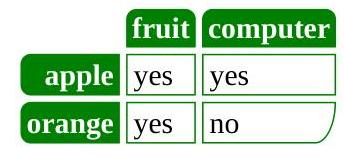

In [107]:
url = "https://www.princexml.com/samples/magic6/magic.pdf"
response = client.ocr.process(model=model, document={"type": "document_url", "document_url": url}, include_image_base64=True)

print(f"Page 0 - markdown:\n\n{response.pages[0].markdown[:200]}\n[...]\n")
print(
    f"Page 0 - image 0 (box: {response.pages[0].images[0].top_left_x}, {response.pages[0].images[0].top_left_y}, {response.pages[0].images[0].bottom_right_x}, {response.pages[0].images[0].bottom_right_y})"
)
display(Image(data=base64.b64decode(response.pages[0].images[0].image_base64.split(",")[1])))

### With requests

In [225]:
url = "https://www.princexml.com/samples/magic6/magic.pdf"
response = requests.post(
    url=f"{server_url}/v1/ocr",
    headers={"Authorization": f"Bearer {api_key}"},
    json={"model": model, "document": {"type": "document_url", "document_url": url}},
)

In [226]:
mistral_response = response.json()
mistral_response["pages"][0]

{'dimensions': {'dpi': 200, 'height': 2689, 'width': 1954},
 'images': [{'bottom_right_x': 777,
   'bottom_right_y': 1949,
   'id': 'img-0.jpeg',
   'image_annotation': None,
   'image_base64': None,
   'top_left_x': 429,
   'top_left_y': 1790},
  {'bottom_right_x': 1254,
   'bottom_right_y': 1072,
   'id': 'img-1.jpeg',
   'image_annotation': None,
   'image_base64': None,
   'top_left_x': 1008,
   'top_left_y': 817}],
 'index': 0,
 'markdown': "# The magic of Prince \n\nPrince is a computer program that converts XML and HTML into PDF. It is simple, yet very powerful, and it creates beautiful documents. The purpose of this small document is to showcase the formatting magic Prince can do. We have chosen to highlight eighteen of our favorite features. This document is written in HTML and converted to PDF by Prince. The source file is a compact 13 k document, including the embedded CSS, SVG and MathML.\n\n## Table of contents\n\n| Hyphenation ................. 1 | Crop and cross marks...

In [ ]:
mistral_response = response.json()
print(mistral_response["pages"][0]["markdown"])

# The magic of Prince 

Prince is a computer program that converts XML and HTML into PDF. It is simple, yet very powerful, and it creates beautiful documents. The purpose of this small document is to showcase the formatting magic Prince can do. We have chosen to highlight eighteen of our favorite features. This document is written in HTML and converted to PDF by Prince. The source file is a compact 13 k document, including the embedded CSS, SVG and MathML.

## Table of contents

| Hyphenation ................. 1 | Crop and cross marks..... 2 |
| :--: | :--: |
| Rounded borders ........... 1 | Cross-references ........... 2 |
| Character substitution .... 1 | Math............................ 2 |
| HTTP support............... 1 | Footnotes...................... 2 |
| Web fonts .................... 1 | Leaders........................ 2 |
| Image resolution............ 1 | SVG ............................ 2 |
| Columns ...................... 1 | Page floats..................... 2 |
| CMYK 

In [18]:
pdf_response = requests.get(url)
pdf_response.raise_for_status()
pdf_base64 = base64.b64encode(pdf_response.content).decode("utf-8")
print(f"Downloaded PDF ({len(pdf_response.content)} bytes) and encoded to base64")

Downloaded PDF (79007 bytes) and encoded to base64


In [45]:
import sys
sys.path.append("../../")
from api.schemas.ocr import ResponseFormat, DocumentURLChunk, ImageURLChunk
class CreateOCR(BaseModel):
    bbox_annotation_format: ResponseFormat | None = Field(default=None, description='Specify the format that the model must output for the bounding boxes. By default it will use `{ "type": "text" }`. Setting to `{ "type": "json_object" }` enables JSON mode, which guarantees the message the model generates is in JSON. When using JSON mode you MUST also instruct the model to produce JSON yourself with a system or a user message. Setting to `{ "type": "json_schema" }` enables JSON schema mode, which guarantees the message the model generates is in JSON and follows the schema you provide.')  # fmt: off
    document: DocumentURLChunk | ImageURLChunk = Field(default=..., description="Document to run OCR on.")  # fmt: off
    document_annotation_format: ResponseFormat | None = Field(default=None, description='Specify the format that the model must output for the document. By default it will use `{ "type": "text" }`. Setting to `{ "type": "json_object" }` enables JSON mode, which guarantees the message the model generates is in JSON. When using JSON mode you MUST also instruct the model to produce JSON yourself with a system or a user message. Setting to `{ "type": "json_schema" }` enables JSON schema mode, which guarantees the message the model generates is in JSON and follows the schema you provide.')  # fmt: off
    # id: str = Field(default=..., description="The ID of the OCR.")  # fmt: off
    image_limit: int | None = Field(default=None, description="Max images to extract")  # fmt: off
    image_min_size: int | None = Field(default=None, description="Minimum height and width of image to extract")  # fmt: off
    include_image_base64: bool | None = Field(default=None, description="Include image URLs in response")  # fmt: off
    model: str | None = Field(default=None, description="The model to use for the OCR.")  # fmt: off
    pages: list[int] | None = Field(default=None, description="Specific pages user wants to process in various formats: single number, range, or list of both. Starts from 0")  # fmt: off


In [77]:

pages = [2, 1, 0]
print(pages_to_ranges(pages))


2,1,0


In [135]:
from pydantic import BaseModel, Field, model_validator
from typing import Literal

class MarkerCreateOCR(CreateOCR):
    page_range: str = Field(default="", description="Page range to convert, specify comma separated page numbers or ranges. Example: '0,5-10,20'")  # fmt: off
    force_ocr: bool = Field(default=False, description="Force OCR on all pages of the PDF.  Defaults to False.  This can lead to worse results if you have good text in your PDFs (which is true in most cases).")  # fmt: off
    paginate_output: Literal[True] = Field(default=True, description="Whether to paginate the output.  Defaults to False.  If set to True, each page of the output will be separated by a horizontal rule that contains the page number (2 newlines, {PAGE_NUMBER}, 48 - characters, 2 newlines).")  # fmt: off
    output_format: Literal["markdown", "json", "html"] = Field(default="markdown", description="The format to output the text in.  Can be 'markdown', 'json', or 'html'.  Defaults to 'markdown'.")  # fmt: off

    class ConfigDict:
        extra = "allow"

    @staticmethod
    def pages_to_page_range(pages: list[int] | None) -> str:
        if not pages:
            return ""

        pages = sorted(pages)
        ranges = []
        start = prev = pages[0]
        for p in pages[1:]:
            if p == prev + 1:
                prev = p
            else:
                ranges.append(f"{start}-{prev}" if start != prev else str(start))
                start = prev = p
        ranges.append(f"{start}-{prev}" if start != prev else str(start))

        return ",".join(ranges)

    @model_validator(mode="after")
    def validate_model(self):
        self.page_range = self.pages_to_page_range(self.pages)
        if self.document_annotation_format is not None:
            match self.document_annotation_format.type:
                case "text":
                    self.output_format = "markdown"
                case "json_object":
                    self.output_format = "json"
                case "json_schema":
                    raise ValueError("json_schema format is not supported for Marker models")
        else:
            self.output_format = "markdown"

        if self.bbox_annotation_format is not None:
            raise ValueError("bbox_annotation_format parameter is not supported for Marker models")

        if self.document_annotation_format is not None:
            raise ValueError("document_annotation_format parameter is not supported for Marker models")

        if self.image_limit is not None:
            raise ValueError("image_limit parameter is not supported for Marker models")

        if self.image_min_size is not None:
            raise ValueError("image_min_size parameter is not supported for Marker models")

        del self.pages
        del self.bbox_annotation_format
        del self.document
        del self.document_annotation_format
        del self.image_limit
        del self.image_min_size
        del self.include_image_base64
        del self.model

        return self


In [137]:
json={"model": model, "document": {"type": "document_url", "document_url": url}, "include_image_base64": True, "force_ocr": True}
MarkerCreateOCR(**json, exclude_none=True)

MarkerCreateOCR(page_range='', force_ocr=True, paginate_output=True, output_format='markdown')

In [201]:
from fastapi import HTTPException
import httpx
import uuid
import base64
from io import BytesIO
server_url = "http://albert.gpu.013.prod.etalab.gouv.fr:8001"
api_key = "tLe553w72ostRtoFSb4YUcA92ihJpr5rLESmqSdrNZ3xhpjsVUaW3szApY2wJcx2"

json={"model": model, "document": {"type": "document_url", "document_url": url}, "include_image_base64": True}
json={"model": model, "document": {"type": "document_url", "document_url": f"data:application/pdf;base64,{pdf_base64}"}, "force_ocr": True, "paginate_output": True}
request_id = str(uuid.uuid4())
document_url = json["document"]["document_url"]
if document_url.startswith("http"):
    async with httpx.AsyncClient() as client:
        try:
            response = await client.get(document_url)
            response.raise_for_status()
            file_content = response.content
        except Exception as e:
            raise HTTPException(status_code=400, detail=f"Failed to download document: {str(e)}")
elif document_url.startswith("data:application/pdf;base64,"):
    try:
        file_content = base64.b64decode(document_url.split(",")[1])
    except Exception as e:
        raise HTTPException(status_code=400, detail=f"Invalid base64 encoded PDF URL: {str(e)}")
else:
    raise HTTPException(status_code=400, detail="Invalid document URL.")

if not file_content.startswith(b"%PDF-"):
    raise HTTPException(status_code=400, detail="Invalid document format (only PDF is supported).")

files = {"file": (f"{request_id}.pdf", BytesIO(file_content), "application/pdf")}
data = MarkerCreateOCR(**json).model_dump()




In [211]:
async with httpx.AsyncClient() as client:
    for i in pages:
        # Create a fresh BytesIO object for each request to avoid stream consumption issues
        response = await client.post(
            url=f"{server_url}/marker/upload",
            files=files,
            json={"test": "test"},
            data=data,
            headers={"Authorization": f"Bearer {api_key}"},
            timeout=120,
        )
        if response.status_code != 200:
            print(response.json())
            raise HTTPException(status_code=response.status_code, detail=response.json().get("detail", "Parsing failed."))

        result = response.json()
        if not result.get("success", False):
            raise HTTPException(status_code=500, detail=result.get("error", "Parsing failed."))

        # metadata = ParsedDocumentMetadata(document_name=params.file.filename, page=i)
        # data.append(ParsedDocumentPage(content=result["output"], images=result["images"], metadata=metadata))



In [212]:
result

{'format': 'markdown',
 'output': '{0}------------------------------------------------\n\n# The *magic* of Prince\n\nPrince is a computer program that converts XML and HTML into PDF. It is simple, yet very powerful, and it creates beautiful documents. The purpose of this small document is to showcase the formatting magic Prince can do. We have chosen to highlight eighteen of our favorite features. This document is written in HTML and converted to PDF by Prince. The source file is a compact 13k document, including the embedded CSS, SVG and MathML.\n\n### **TABLE OF CONTENTS**\n\n| Hyphenation                          |  |\n|--------------------------------------|--|\n| Rounded borders 1 Cross-references 2 |  |\n| Character substitution 1 Math        |  |\n| HTTP support1 Footnotes              |  |\n| Web fonts                            |  |\n| Image resolution                     |  |\n| Columns                              |  |\n| CMYK colors                          |  |\n| Counters

MarkerOCR(document_annotation=None, id=None, model=None, pages=[OCRPageObject(dimensions=None, images=[OCRImageObject(bottom_right_x=None, bottom_right_y=None, id='_page_0_Picture_12.jpeg', image_annotation=None, image_base64='', top_left_x=None, top_left_y=None)], index=0, markdown="# The *magic* of Prince\n\nPrince is a computer program that converts XML and HTML into PDF. It is simple, yet very powerful, and it creates beautiful documents. The purpose of this small document is to showcase the formatting magic Prince can do. We have chosen to highlight eighteen of our favorite features. This document is written in HTML and converted to PDF by Prince. The source file is a compact 13k document, including the embedded CSS, SVG and MathML.\n\n### **TABLE OF CONTENTS**\n\n| Hyphenation                          |  |\n|--------------------------------------|--|\n| Rounded borders 1 Cross-references 2 |  |\n| Character substitution 1 Math        |  |\n| HTTP support1 Footnotes              |
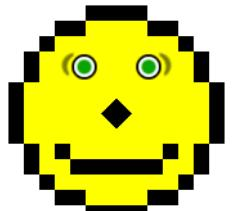
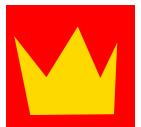

In [ ]:
from api.schemas.ocr import OCR, OCRPageObject, OCRImageObject, OCRUsage
import re
from pydantic import BaseModel, Field, model_validator
from typing import Literal, Any

class MarkerOCR(OCR):
    format: Literal["markdown", "json", "html"]
    output: str
    images: dict[str, str]
    metadata: dict[str, Any]
    success: bool

    @model_validator(mode="before")
    def validate_model_before(cls, values):
        values["pages"] = []
        content = response.json()["output"]
        images = response.json()["images"]
        matches = list(re.finditer(r"\{[0-9]+\}-{48}\n\n", content))
        for i in range(len(matches)):
            offset = len(content) if i == len(matches) - 1 else matches[i+1].span()[0]
            markdown = content[matches[i].span()[1]:offset]
            images_page = [OCRImageObject(id=key, image_base64=f"data:image/jpeg;base64,{value}") for key, value in images.items() if key.startswith(f"_page_{i}_")]
            values["pages"].append(OCRPageObject(index=i, markdown=markdown, images=images_page))

        values["usage_info"] = OCRUsage(doc_size_bytes=values.get("usage_info", {}).get("doc_size_bytes"), pages_processed=len(matches))
        return values

    @model_validator(mode="after")
    def validate_model_after(self):
        del self.format
        del self.output
        del self.images
        del self.metadata
        del self.success

        return self

MarkerOCR(**response.json())

In [191]:
class Subtest(BaseModel):
    test: str

class Test(Subtest):
    test2: str


    @model_validator(mode="before")
    def validate_model(cls, values):
        values["test"] = "test"
        return values

Test(test2="test")

Test(test='test', test2='test')

In [ ]:
import re

pages = []
content = response.json()["output"]
images = response.json()["images"]
matches = list(re.finditer(r"\{[0-9]+\}-{48}\n\n", content))
for i in range(len(matches)):
    offset = len(content) if i == len(matches) - 1 else matches[i+1].span()[0]
    markdown = content[matches[i].span()[1]:offset]
    images_page = [OCRImageObject(id=key, image_base64=f"data:image/jpeg;base64,{value}") for key, value in images.items() if key.startswith(f"_page_{i}_")]
    pages.append(OCRPageObject(index=i, markdown=markdown, images=images_page))

{'document_annotation': None,
 'id': 'request-703d4c44e27d42ada187c0a5aa6b121e',
 'model': 'mistral-ocr-2505',
 'pages': [{'dimensions': {'dpi': 200, 'height': 2689, 'width': 1954},
   'images': [{'bottom_right_x': 777,
     'bottom_right_y': 1949,
     'id': 'img-0.jpeg',
     'image_annotation': None,
     'image_base64': '',
     'top_left_x': 433,
     'top_left_y': 1790},
    {'bottom_right_x': 1256,
     'bottom_right_y': 1072,
     'id': 'img-1.jpeg',
     'image_annotation': None,
     'image_base64': '',
     'top_left_x': 1008,
     'top_left_y': 817}],
   'index': 0,
   'markdown': "# The magic of Prince \n\nPrince is a computer program that converts XML and HTML into PDF. It is simple, yet very powerful, and it creates beautiful documents. The purpose of this small document is to showcase the formatting magic Prince can do. We have chosen to highlight eighteen of our favorite features. This document is written in HTML and converted to PDF by Prince. The source file is a com
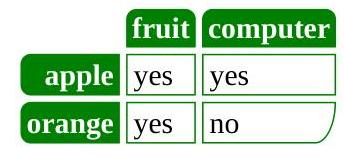
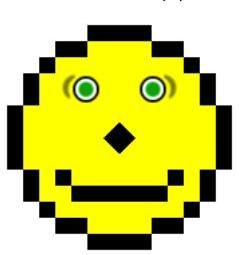

In [200]:
mistral_response

In [176]:
response.json()["images"]

{'_page_0_Picture_12.jpeg': '/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjL/wAARCADTAPYDASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJipKTlJWWl5iZmqKjpKWmp6ipqrKztLW2t7i5usLDxMXGx8jJytLT1NXW19jZ2uHi4+Tl5ufo6erx8vP09fb3+Pn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3+Pn6/9oADAMBAAIRAxEAPwD3+iiigAooooAKKKKACiiigAooooAxvFHifTvCOiSavqhlFqjqh8pNzZY4HFcL/wANA+CP72o/+A3/ANepvj1/ySy7/wCvmH/0Kvk2gD6s/wCGgfBH97Uf/Ab/AOvR/wANA+CP72o/+A3

In [174]:
print(content)

{0}------------------------------------------------

# The *magic* of Prince

Prince is a computer program that converts XML and HTML into PDF. It is simple, yet very powerful, and it creates beautiful documents. The purpose of this small document is to showcase the formatting magic Prince can do. We have chosen to highlight eighteen of our favorite features. This document is written in HTML and converted to PDF by Prince. The source file is a compact 13k document, including the embedded CSS, SVG and MathML.

### **TABLE OF CONTENTS**

| Hyphenation                          |  |
|--------------------------------------|--|
| Rounded borders 1 Cross-references 2 |  |
| Character substitution 1 Math        |  |
| HTTP support1 Footnotes              |  |
| Web fonts                            |  |
| Image resolution                     |  |
| Columns                              |  |
| CMYK colors                          |  |
| Counters                             |  |

#### #1: Hyphenat

In [ ]:
print()

{0}------------------------------------------------

# The *magic* of Prince

Prince is a computer program that converts XML and HTML into PDF. It is simple, yet very powerful, and it creates beautiful documents. The purpose of this small document is to showcase the formatting magic Prince can do. We have chosen to highlight eighteen of our favorite features. This document is written in HTML and converted to PDF by Prince. The source file is a compact 13k document, including the embedded CSS, SVG and MathML.

### **TABLE OF CONTENTS**

| Hyphenation                          |  |
|--------------------------------------|--|
| Rounded borders 1 Cross-references 2 |  |
| Character substitution 1 Math        |  |
| HTTP support1 Footnotes              |  |
| Web fonts                            |  |
| Image resolution                     |  |
| Columns                              |  |
| CMYK colors                          |  |
| Counters                             |  |

#### #1: Hyphenat

In [91]:
print(api_key)

c79BcWCPAoaPKgTXLmIifRF5DKSyMCAsiCGjEdIxRJhyA5UP5CEg1udJAv6d1Jxl


Page 0 - markdown:

# The magic of Prince 

Prince is a computer program that converts XML and HTML into PDF. It is simple, yet very powerful, and it creates beautiful documents. The purpose of this small document is to 
[...]

Page 0 - image 0 (box: 433, 1790, 777, 1949)


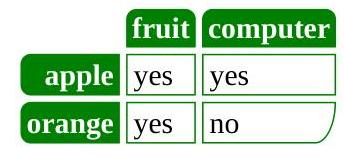

In [ ]:

response = response.json()

print(f"Page 0 - markdown:\n\n{response["pages"][0]["markdown"][:200]}\n[...]\n")
print(
    f"Page 0 - image 0 (box: {response["pages"][0]["images"][0]["top_left_x"]}, {response["pages"][0]["images"][0]["top_left_y"]}, {response["pages"][0]["images"][0]["bottom_right_x"]}, {response["pages"][0]["images"][0]["bottom_right_y"]})"
)
display(Image(data=base64.b64decode(response["pages"][0]["images"][0]["image_base64"].split(",")[1])))

### OCR with a base64 encoded PDF

### With Mistral client

Downloaded PDF (135171 bytes) and encoded to base64

Page 0 - markdown:

# Anatomy of the Somatosensory System 

From WIKIbOOKs ${ }^{1}$

Our somatosensory system consists of sensors in the skin and sensors in our muscles, tendons, and joints. The receptors in the skin, t
[...]

Page 0 - image 0 (box: 143, 1075, 965, 1705)


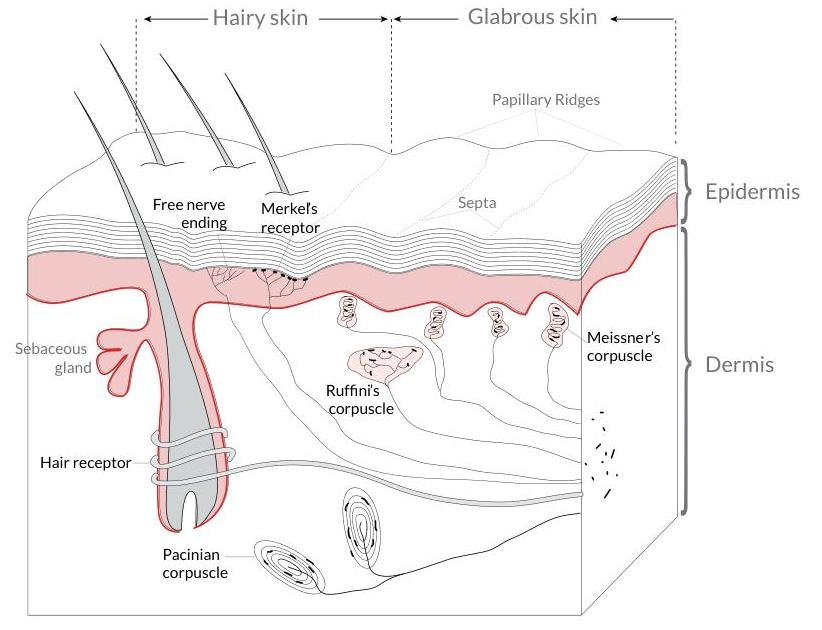

In [ ]:
# Download the PDF and encode it to base64
pdf_url = "https://www.princexml.com/samples/textbook/somatosensory.pdf"
pdf_response = requests.get(pdf_url)
pdf_response.raise_for_status()
pdf_base64 = base64.b64encode(pdf_response.content).decode("utf-8")
print(f"Downloaded PDF ({len(pdf_response.content)} bytes) and encoded to base64")

# Process OCR
response = client.ocr.process(
    model=model, document={"type": "document_url", "document_url": f"data:application/pdf;base64,{pdf_base64}"}, include_image_base64=True
)


print(f"\nPage 0 - markdown:\n\n{response.pages[0].markdown[:200]}\n[...]\n")
if response.pages[0].images:
    print(
        f"Page 0 - image 0 (box: {response.pages[0].images[0].top_left_x}, {response.pages[0].images[0].top_left_y}, {response.pages[0].images[0].bottom_right_x}, {response.pages[0].images[0].bottom_right_y})"
    )
    display(Image(data=base64.b64decode(response.pages[0].images[0].image_base64.split(",")[1])))

### With requests

Page 0 - markdown:

# Anatomy of the Somatosensory System 

From WIKIbOOKs ${ }^{1}$

Our somatosensory system consists of sensors in the skin and sensors in our muscles, tendons, and joints. The receptors in the skin, t
[...]

Page 0 - image 0 (box: 143, 1075, 965, 1705)


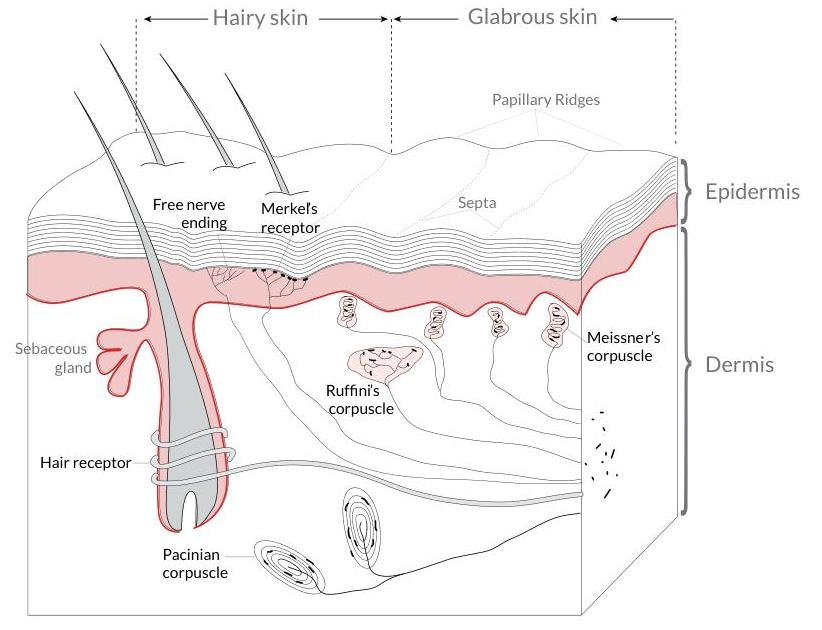

In [7]:
# Option 2 - with requests
response = requests.post(
    url=f"{server_url}/v1/ocr",
    headers={"Authorization": f"Bearer {api_key}"},
    json={
        "model": model,
        "document": {"type": "document_url", "document_url": f"data:application/pdf;base64,{pdf_base64}"},
        "include_image_base64": True,
    },
)
response = response.json()

print(f"Page 0 - markdown:\n\n{response["pages"][0]["markdown"][:200]}\n[...]\n")
if response["pages"][0].get("images"):
    print(
        f"Page 0 - image 0 (box: {response["pages"][0]["images"][0]["top_left_x"]}, {response["pages"][0]["images"][0]["top_left_y"]}, {response["pages"][0]["images"][0]["bottom_right_x"]}, {response["pages"][0]["images"][0]["bottom_right_y"]})"
    )
    display(Image(data=base64.b64decode(response["pages"][0]["images"][0]["image_base64"].split(",")[1])))

## OCR your images

### OCR with a image URL

### With Mistral client

In [8]:
image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/0/0b/ReceiptSwiss.jpg/1280px-ReceiptSwiss.jpg"

response = client.ocr.process(model=model, document={"type": "image_url", "image_url": image_url}, include_image_base64=True)

print(f"Markdown:\n\n{response.pages[0].markdown[:200]}\n[...]\n")

Markdown:

Berghotel
Grosse Scheidegg
3818 Grindelwald
Familie R.Müller

Rech. Nr. 4572 30.07.2007/13:29:17
Bar Tisch 7/01

2xLatte Macchiato à 4.50 CHF 9.00
1xGloki à 5.00 CHF 5.00
1xSchweinschnitzel à 22.00 CH
[...]



### With requests

In [9]:
image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/0/0b/ReceiptSwiss.jpg/1280px-ReceiptSwiss.jpg"
response = requests.post(
    url=f"{server_url}/v1/ocr",
    headers={"Authorization": f"Bearer {api_key}"},
    json={"model": model, "document": {"type": "image_url", "image_url": image_url}, "include_image_base64": True},
)
response = response.json()

print(f"Markdown:\n\n{response["pages"][0]["markdown"][:200]}\n[...]\n")

Markdown:

Berghotel
Grosse Scheidegg
3818 Grindelwald
Familie R.Müller

Rech. Nr. 4572 30.07.2007/13:29:17
Bar Tisch 7/01

2xLatte Macchiato à 4.50 CHF 9.00
1xGloki à 5.00 CHF 5.00
1xSchweinschnitzel à 22.00 CH
[...]



### OCR with a base64 encoded image

### With Mistral client

In [10]:
# Download an image and encode it to base64
image_url = "https://ocr.space/Content/Images/receipt-ocr-original.webp"
image_response = requests.get(image_url)
image_response.raise_for_status()

# Encode image bytes directly to base64 (no PIL needed)
image_base64 = base64.b64encode(image_response.content).decode("utf-8")
print(f"Downloaded image and encoded to base64 ({len(image_base64)} characters)")

# Process OCR
response = client.ocr.process(model=model, document={"type": "image_url", "image_url": image_url}, include_image_base64=True)

print(f"\nMarkdown:\n\n{response.pages[0].markdown[:200]}\n[...]\n")
if response.pages[0].images:
    print(
        f"Image 0 (box: {response.pages[0].images[0].top_left_x}, {response.pages[0].images[0].top_left_y}, {response.pages[0].images[0].bottom_right_x}, {response.pages[0].images[0].bottom_right_y})"
    )
    display(Image(data=base64.b64decode(response.pages[0].images[0].image_base64.split(",")[1])))

Downloaded image and encoded to base64 (151020 characters)

Markdown:

# Walmart
Save money. Live better.
(330) 339 - 3991
MANAGER DIANA EARNEST
231 BLUEBELL DR SW
NEW PHILADELPHIA OH 44663
ST# 02115 OP# 009044 TE# 44 TR# 01301
PET TOY 004747571658 1.97 X
FLOPPY PUPPY 00
[...]



### With request

In [ ]:
# Download an image and encode it to base64
image_url = "https://ocr.space/Content/Images/receipt-ocr-original.webp"
image_response = requests.get(image_url)
image_response.raise_for_status()

# Encode image bytes directly to base64 (no PIL needed)
image_base64 = base64.b64encode(image_response.content).decode("utf-8")
print(f"Downloaded image and encoded to base64 ({len(image_base64)} characters)")

# Process OCR
response = requests.post(
    url=f"{server_url}/v1/ocr",
    headers={"Authorization": f"Bearer {api_key}"},
    json={"model": model, "document": {"type": "image_url", "image_url": image_url}, "include_image_base64": True},
)
response = response.json()

print(f"\nMarkdown:\n\n{response["pages"][0]["markdown"][:200]}\n[...]\n")

Downloaded image and encoded to base64 (151020 characters)

Markdown:

# Walmart
Save money. Live better.
(330) 339 - 3991
MANAGER DIANA EARNEST
231 BLUEBELL DR SW
NEW PHILADELPHIA OH 44663
ST# 02115 OP# 009044 TE# 44 TR# 01301
PET TOY 004747571658 1.97 X
FLOPPY PUPPY 00
[...]

